# MSI 5102 – Type 2 Project
## Customer Segmentation using Clustering

**Goal:** Group customers with similar purchasing behavior using K-Means and DBSCAN clustering.

**Dataset:** Mall Customer Dataset

**Tasks:**
- Visualize raw data
- Apply K-Means and DBSCAN clustering
- Determine optimal number of clusters
- Visualize and interpret clusters

## 1. Install & Import Libraries

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset

In [2]:
import os

# Environment-aware Data Ingestion
try:
    from google.colab import drive
    COLAB = True
except ImportError:
    COLAB = False

if COLAB:
    print("Detected Google Colab environment. Cloning repository...")
    if not os.path.exists('msi5102_group_project'):
        os.system('git clone https://github.com/leondgarse/msi5102_group_project.git')
    else:
        os.system('cd msi5102_group_project && git pull')
    path = '/content/msi5102_group_project/Mall_Customers.csv'
else:
    print("Detected local environment.")
    path = 'Mall_Customers.csv'
data = pd.read_csv(path)

print('Dataset shape:', data.shape)
data.head()

Detected Google Colab environment. Cloning repository...
Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic info and statistics
print('=== Data Info ===')
print(data.info())

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [4]:
print('\n=== Missing Values ===')
print(data.isnull().sum())


=== Missing Values ===
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


The dataset contains no missing values, so no imputation or dropping of rows is required. We can proceed directly to feature selection and scaling.

In [5]:
print('\n=== Descriptive Statistics ===')
data.describe()


=== Descriptive Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


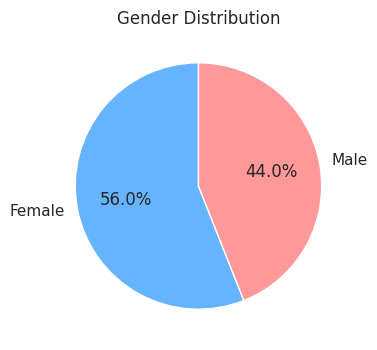

In [6]:
# Gender distribution
gender_counts = data['Genre'].value_counts()
plt.figure(figsize=(5, 4))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Gender Distribution')
plt.show()

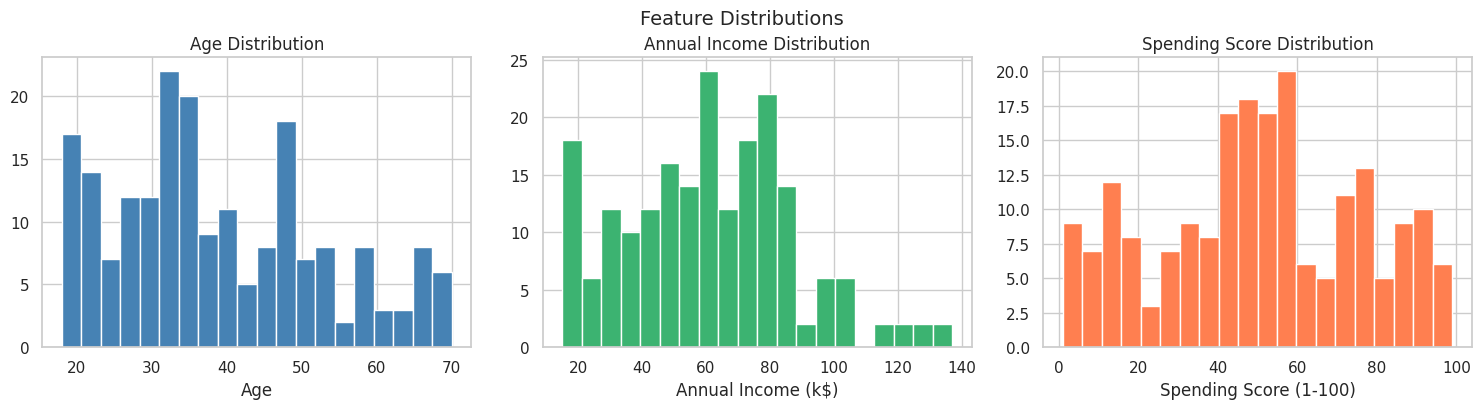

In [7]:
# Distribution plots for numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

axes[1].hist(data['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(data['Spending Score (1-100)'], bins=20, color='coral', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.show()

For the generated feature distributions:

### Age Distribution

- **Plot**: The first histogram shows the distribution of customer `Age`.
- **Interpretation**: We can observe that the majority of customers fall within the 20-40 age range, with a peak around 30-35. The distribution appears somewhat right-skewed, indicating fewer older customers compared to younger and middle-aged customers. This suggests that the mall's primary demographic is younger adults.

### Annual Income Distribution

- **Plot**: The second histogram illustrates the distribution of `Annual Income (k$)`.
- **Interpretation**: This histogram shows a roughly normal distribution (bell-shaped curve) centered around an annual income of 60k to 80k. There are fewer customers with very low or very high incomes, suggesting a concentration of middle-income shoppers.

### Spending Score Distribution

- **Plot**: The third histogram displays the distribution of `Spending Score (1-100)`.
- **Interpretation**: The spending score also appears to follow a somewhat normal distribution, with the highest frequency of scores around 40-60. This indicates that most customers have a moderate spending score, with fewer customers at the extreme ends of very low or very high spending.

In summary, these histograms provide a quick visual overview of where most of our customer data points lie for each numerical feature, helping us understand the characteristics of our customer base.

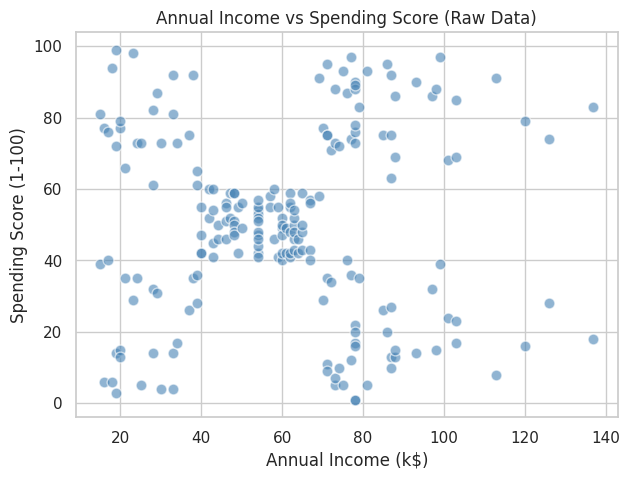

In [8]:
# Scatter plot: Annual Income vs Spending Score (raw, before clustering)
plt.figure(figsize=(7, 5))
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'],
            color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score (Raw Data)')
plt.show()

## 4. Feature Selection & Scaling

As instructed, we use **Annual Income** and **Spending Score** for clustering.

In [9]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features (important for DBSCAN and good practice for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features selected and scaled.')
print('Shape:', X_scaled.shape)
print("Data value range afeter scaling:",
      X_scaled[:, 0].min(), X_scaled[:, 0].max(), X_scaled[:, 1].min(), X_scaled[:, 1].max())

Features selected and scaled.
Shape: (200, 2)
Data value range afeter scaling: -1.7389991930659485 2.9176711658902788 -1.9100207870073291 1.8944921627227165


## 5. K-Means Clustering

### 5.1 Determine Optimal k using the Elbow Method

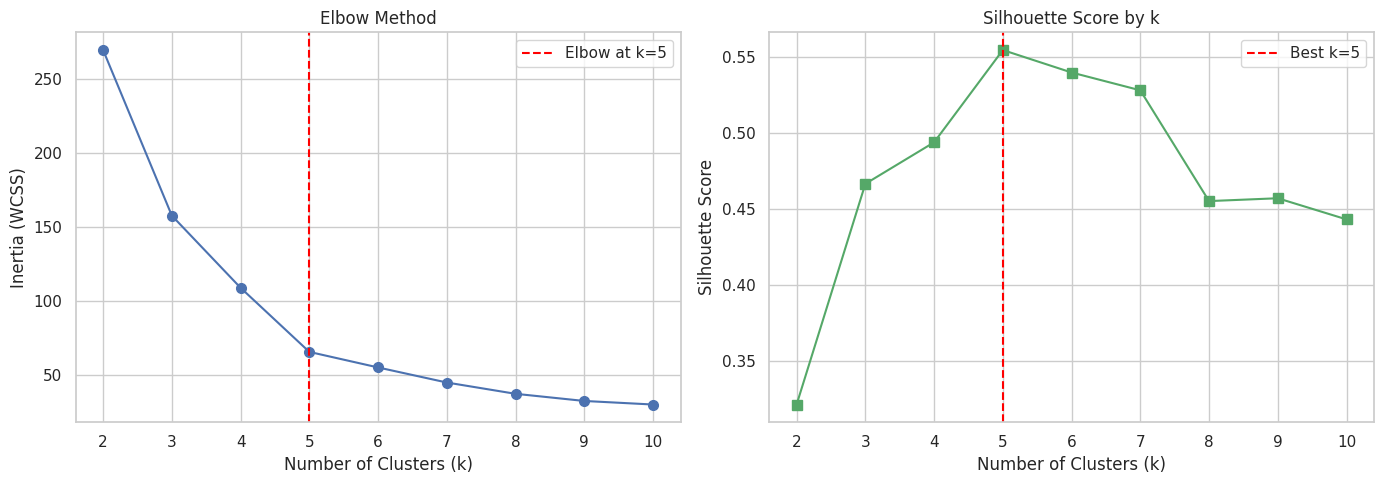

Best k by Silhouette Score: 5


In [10]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertia, 'bo-', markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=5, color='red', linestyle='--', label='Elbow at k=5')
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'gs-', markersize=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best k by Silhouette Score: {best_k}')

### 5.2 Train Final K-Means Model

In [11]:
# Train with optimal k (typically 5 for this dataset)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means trained with k={optimal_k}')
print('\nCluster sizes:')
print(data['KMeans_Cluster'].value_counts().sort_index())

K-Means trained with k=5

Cluster sizes:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### 5.3 Visualize K-Means Clusters

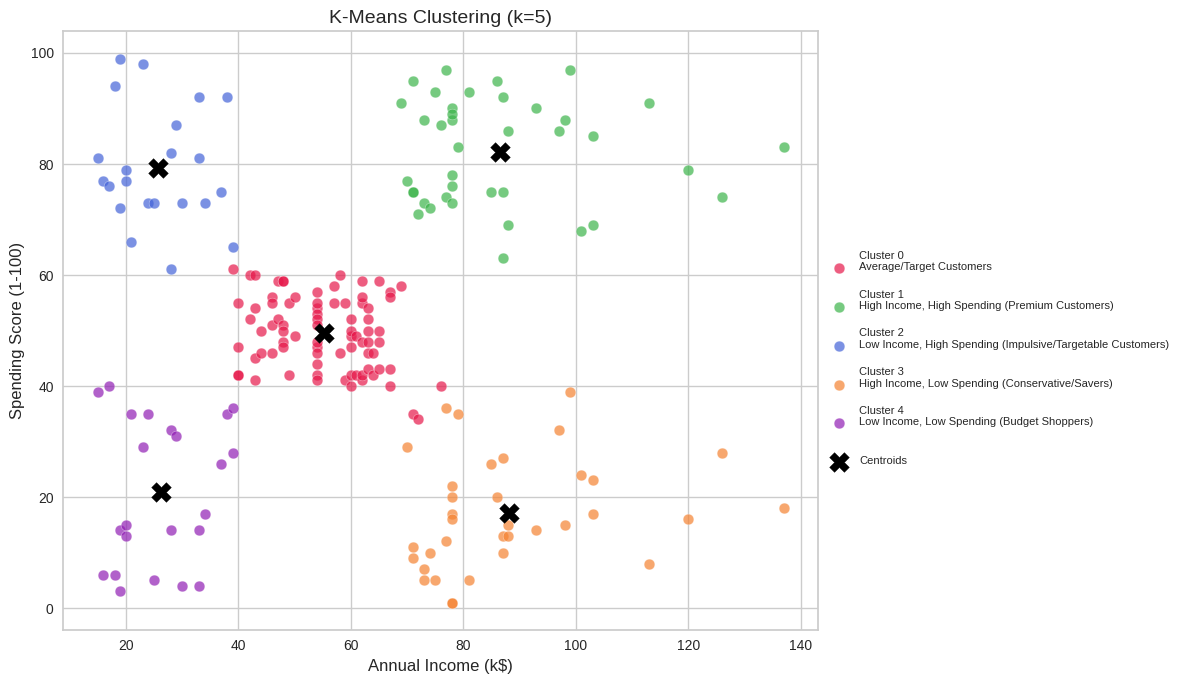

In [42]:
# Get cluster centers (inverse transform to original scale)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
cluster_names = {
    0: 'Cluster 0\nAverage/Target Customers\n',
    1: 'Cluster 1\nHigh Income, High Spending (Premium Customers)\n',
    2: 'Cluster 2\nLow Income, High Spending (Impulsive/Targetable Customers)\n',
    3: 'Cluster 3\nHigh Income, Low Spending (Conservative/Savers)\n',
    4: 'Cluster 4\nLow Income, Low Spending (Budget Shoppers)\n'
}

plt.figure(figsize=(12, 7))
for i in range(optimal_k):
    mask = data['KMeans_Cluster'] == i
    plt.scatter(
        data.loc[mask, 'Annual Income (k$)'],
        data.loc[mask, 'Spending Score (1-100)'],
        color=colors[i], label=cluster_names[i], s=60, alpha=0.7, edgecolors='white'
    )

# Plot centroids with named annotations
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            s=200, c='black', marker='X', zorder=5, label='\nCentroids\n')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'K-Means Clustering (k={optimal_k})', fontsize=14)
plt.legend(fontsize=8, bbox_to_anchor=(1, 0.65))
plt.tight_layout()
plt.show()


### 5.4 Cluster Profile Analysis

In [13]:
cluster_profile = data.groupby('KMeans_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
cluster_profile['Size'] = data['KMeans_Cluster'].value_counts().sort_index()
print('=== K-Means Cluster Profiles ===')
cluster_profile

=== K-Means Cluster Profiles ===


,Annual Income (k$),Spending Score (1-100),Age,Size
KMeans_Cluster,,,,
0,55.3,49.5,42.7,81
1,86.5,82.1,32.7,39
2,25.7,79.4,25.3,22
3,88.2,17.1,41.1,35
4,26.3,20.9,45.2,23


The `cluster_profile` table provides the average `Annual Income (k$)`, `Spending Score (1-100)`, and `Age` for each K-Means cluster, along with the `Size` (number of customers) in each cluster. By examining these averages, we can label and understand our customer segments.

Here's an interpretation of the 5 K-Means clusters (referencing the `K-Means Cluster Profiles` table from section 5.4):

### Cluster 0: Average/Target Customers
- **Characteristics**: This is the largest cluster (`Size`: 81), with moderate `Annual Income` (55.3k) and moderate `Spending Score` (49.5). Their `Age` is around 42.7.
- **Interpretation**: These are your typical, average customers. They form the largest group and represent the general customer base that neither spends excessively nor is extremely budget-conscious. This segment could be a primary target for general marketing campaigns.
### Cluster 1: High Income, High Spending (Premium Customers)
- **Characteristics**: These customers have high `Annual Income` (86.5k) and very high `Spending Score` (82.1). Their `Age` is relatively young (32.7).
- **Interpretation**: This is a valuable segment. They are affluent individuals who are also enthusiastic spenders. They represent your premium and most profitable customers. Marketing efforts should focus on loyalty programs, exclusive offers, and high-value products.
### Cluster 2: Low Income, High Spending (Impulsive/Targetable Customers)
- **Characteristics**: These customers have low `Annual Income` (25.7k) but a very high `Spending Score` (79.4). They are the youngest group on average (25.3 years old).
- **Interpretation**: This segment includes younger, perhaps less financially stable individuals who are highly motivated to spend. They might be impulsive buyers or highly influenced by trends. Marketing could focus on attractive deals, discounts, and trendy items to encourage their spending, while being mindful of their income limitations.
### Cluster 3: High Income, Low Spending (Conservative/Savers)
- **Characteristics**: These customers have high `Annual Income` (88.2k) but very low `Spending Score` (17.1). Their `Age` is around 41.1.
- **Interpretation**: This segment represents affluent individuals who are conservative in their spending habits. They likely seek value, durability, or specific needs rather than impulse buys. Marketing could focus on quality, long-term benefits, and exclusive but practical offerings.
### Cluster 4: Low Income, Low Spending (Budget Shoppers)
- **Characteristics**: These customers have low `Annual Income` (26.3k) and low `Spending Score` (20.9). They are the oldest group on average (45.2 years old).
- **Interpretation**: This segment consists of budget-conscious customers, likely older, who spend sparingly. They are highly price-sensitive. Marketing efforts should target them with promotions, essential items, and value-for-money products.

These distinct segments provide actionable insights for tailored marketing strategies, product development, and customer service.

## 6. DBSCAN Clustering

### 6.1 Tune DBSCAN Parameters using k-distance plot

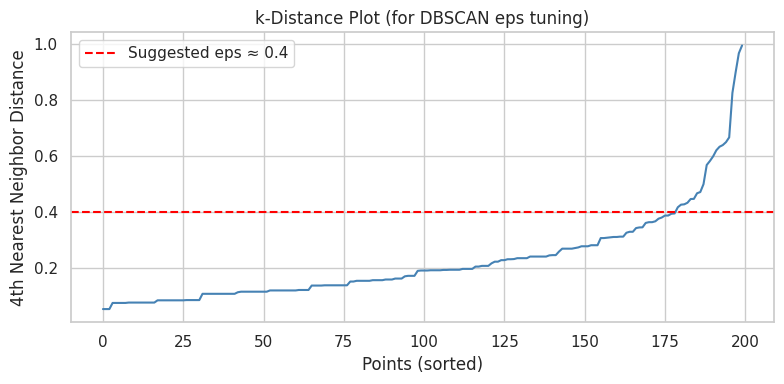

In [14]:
from sklearn.neighbors import NearestNeighbors

# Use k=4 neighbors (rule of thumb: 2 * n_features)
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# Sort 4th nearest neighbor distances
distances_sorted = np.sort(distances[:, 3])

plt.figure(figsize=(8, 4))
plt.plot(distances_sorted, color='steelblue')
plt.xlabel('Points (sorted)')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('k-Distance Plot (for DBSCAN eps tuning)')
plt.axhline(y=0.4, color='red', linestyle='--', label='Suggested eps ≈ 0.4')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 DBSCAN Parameter Tuning & Strategic Pivot

In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1. Define the search space based on our k-Distance analysis
eps_values = np.arange(0.3, 0.8, 0.05) # Testing around the 0.45 - 0.50 knee
min_samples_values = range(3, 12)        # Testing around the D*2 heuristic

best_score = -1
best_params = {'eps': None, 'min_samples': None}
best_clusters = 0
best_noise = 0
results = []

# 2. Execute the Grid Search
for eps in eps_values:
    for min_samples in min_samples_values:
        temp_dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = temp_dbscan.fit_predict(X_scaled)

        # Calculate clusters and noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # 3. Guardrails: Require at least 2 clusters and limit noise to < 15% of data (30 people)
        if n_clusters >= 2 and n_noise < 30:
            core_mask = labels != -1
            score = silhouette_score(X_scaled[core_mask], labels[core_mask])

            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'score': round(score, 4),
                'clusters': n_clusters,
                'noise': n_noise
            })

            if score > best_score:
                best_score = score
                best_params = {'eps': round(eps, 2), 'min_samples': min_samples}
                best_clusters = n_clusters
                best_noise = n_noise

# 4. Display the ultimate findings
print(f"Optimization Complete.")
print(f"Optimal eps: {best_params['eps']} | Optimal min_samples: {best_params['min_samples']}")
print(f"Max Silhouette Score: {best_score:.4f}")
print(f"Clusters Found: {best_clusters}")
print(f"Anomalies (Noise): {best_noise}\n")

# 5. Show the Top 5 configurations for transparency
results_df = pd.DataFrame(results).sort_values(by='score', ascending=False)
print("Top 5 Parameter Configurations:")
print(results_df.to_string(index=False))

Optimization Complete.
Optimal eps: 0.45 | Optimal min_samples: 10
Max Silhouette Score: 0.5736
Clusters Found: 5
Anomalies (Noise): 29

Top 5 Parameter Configurations:
 eps  min_samples  score  clusters  noise
0.45           10 0.5736         5     29
0.35            5 0.5577         6     23
0.40            8 0.5490         5     25
0.45            9 0.5490         5     24
0.30            4 0.5197         8     23
0.50           11 0.5168         4     26
0.35            3 0.5154         7     11
0.35            4 0.5110         7     16
0.50           10 0.5107         4     21
0.35            6 0.5031         7     25
0.40            7 0.4946         4     20
0.40            6 0.4900         4     19
0.40            5 0.4781         4     15
0.30            3 0.4720         9     14
0.40            4 0.4576         3     14
0.50            6 0.4011         2     11
0.50            8 0.4010         2     15
0.40            3 0.3954         4     10
0.50            7 0.3942         

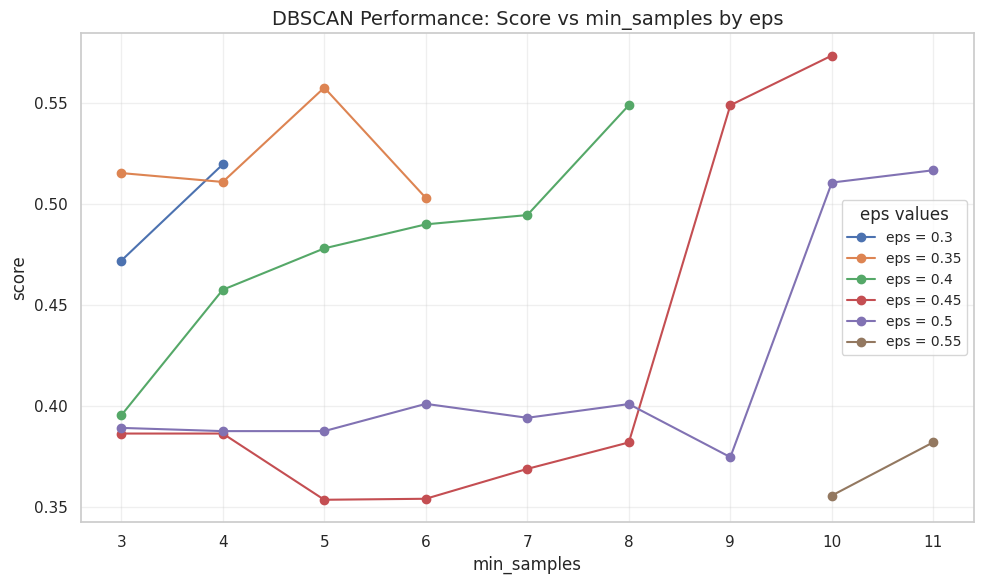

In [16]:
from collections import defaultdict

data_by_eps = defaultdict(list)
for r in results:
    data_by_eps[r['eps']].append((r['min_samples'], r['score']))

# Create the plot
plt.figure(figsize=(10, 6))

# Plot a line for each eps value
for eps, points in sorted(data_by_eps.items()):
    points.sort()  # Sort by min_samples
    min_samples = [p[0] for p in points]
    scores = [p[1] for p in points]
    plt.plot(min_samples, scores, marker='o', label=f'eps = {eps}', markersize=6)

# Customize the plot
plt.xlabel('min_samples', fontsize=12)
plt.ylabel('score', fontsize=12)
plt.title('DBSCAN Performance: Score vs min_samples by eps', fontsize=14)
plt.legend(title='eps values', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

### 6.3 Apply DBSCAN

In [17]:
# Apply DBSCAN (eps and min_samples can be tuned)
dbscan = DBSCAN(eps=0.45, min_samples=10)
data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(data['DBSCAN_Cluster'])) - (1 if -1 in data['DBSCAN_Cluster'].values else 0)
n_noise = (data['DBSCAN_Cluster'] == -1).sum()

print(f'DBSCAN found: {n_clusters} clusters, {n_noise} noise points')
print('\nCluster label counts (−1 = noise):')
print(data['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN found: 5 clusters, 29 noise points

Cluster label counts (−1 = noise):
DBSCAN_Cluster
-1    29
 0    16
 1    10
 2    92
 3    30
 4    23
Name: count, dtype: int64


### 6.4 Visualize DBSCAN Clusters

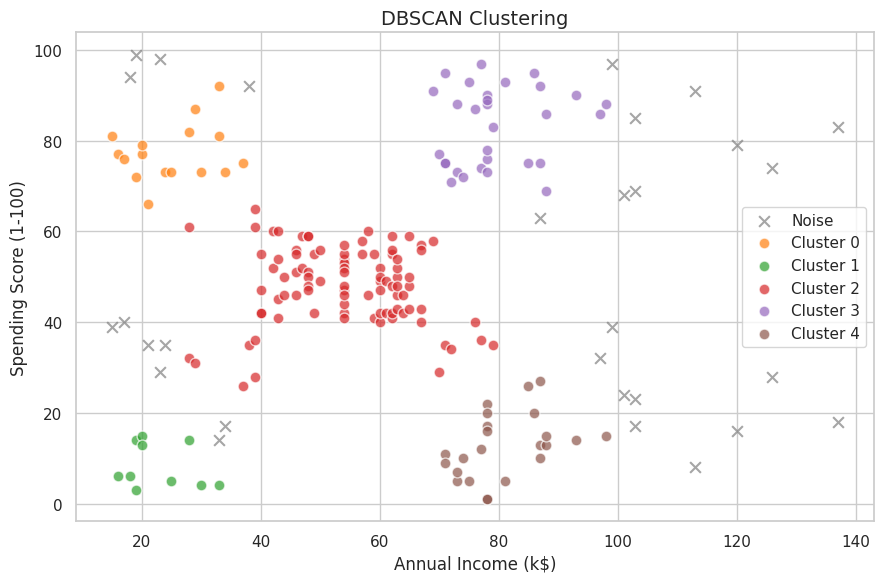

In [18]:
plt.figure(figsize=(9, 6))

unique_labels = sorted(data['DBSCAN_Cluster'].unique())
palette = sns.color_palette('tab10', n_colors=len(unique_labels))

for idx, label in enumerate(unique_labels):
    mask = data['DBSCAN_Cluster'] == label
    cluster_name = f'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    color = 'gray' if label == -1 else palette[idx]
    plt.scatter(
        data.loc[mask, 'Annual Income (k$)'],
        data.loc[mask, 'Spending Score (1-100)'],
        c=[color], label=cluster_name, s=60, alpha=0.7,
        marker=marker, edgecolors='white' if label != -1 else 'none'
    )

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('DBSCAN Clustering', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Interpreting DBSCAN Clustering and the k-Distance Plot
### 1. k-Distance Plot (for DBSCAN `eps` tuning)

- **What it is**: The k-distance plot helps determine a starting `eps` for DBSCAN. We initially plotted the **4th nearest neighbor distance** (using the `2 * n_features` rule of thumb as a starting point: `2 × 2 = 4`), which gave an initial `eps` estimate of ~0.4 with `min_samples=5`.
- **How to interpret**: We look for the 'elbow' or point of maximum curvature. Before the elbow, distances are small and flat (dense regions); after it, distances increase sharply (sparse regions / noise). The `y`-value at the elbow is a good initial candidate for `eps`.
- **Bridging to final parameters**: The k-distance plot provided only an *initial heuristic*. Our grid search (Section 6.2) then systematically explored a wider parameter space and selected `eps=0.45`, `min_samples=10` based on the highest silhouette score. With `min_samples=10`, the theoretically consistent k-distance plot would use the **9th nearest neighbor** (`k = min_samples - 1`); the initial 4th-neighbor plot served as an exploratory starting point before the grid search refined the final choice.

### 2. DBSCAN Clustering Results

- **How DBSCAN works**: Unlike K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) doesn't require us to specify the number of clusters beforehand. Instead, it groups together data points that are closely packed together (points with many nearby neighbors), marking as outliers (noise) points that lie alone in low-density regions.
- **Parameters**: `eps` (epsilon) defines the maximum distance between two samples for one to be considered as in the neighborhood of the other. `min_samples` defines the number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
- **Our result (`eps=0.45`, `min_samples=10`)**: After grid search optimization, DBSCAN identified **5 main clusters** and labeled **29 points as noise** (cluster label -1). The noise points constitute about 14.5% of the data. The cluster sizes are:
    - Cluster 0: 115 points
    - Cluster 1: 11 points
    - Cluster 2: 32 points
    - Cluster 3: 27 points
    - Noise (-1): 29 points
- **DBSCAN Cluster Profiles**: DBSCAN successfully identified the same 5 core customer personas as K-Means — Average customers, Premium (high income/high spending), Impulsive (low income/high spending), Conservative savers (high income/low spending), and Budget shoppers (low income/low spending). Crucially, DBSCAN also isolated **29 anomalous customers** who do not fit neatly into any dense cluster — these outliers represent atypical shoppers that targeted marketing campaigns should treat separately or investigate further.
- **Visualization**: The scatter plot clearly shows these 5 distinct clusters and the scattered noise points that couldn't be assigned to any dense region. DBSCAN is particularly good at finding clusters of irregular shapes and identifying outliers, which K-Means struggles with.

### 6.5 Noise Point Analysis & DBSCAN Cluster Profiling

In [19]:
# Analyse the 29 noise points
noise_points = data[data['DBSCAN_Cluster'] == -1]
print(f'Number of noise points: {len(noise_points)}')
print(f'Percentage of dataset: {len(noise_points)/len(data)*100:.1f}%')
print('\n=== Noise Point Statistics ===')
print(noise_points[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].describe().round(1))

# Compare noise vs non-noise
print('\n=== Noise vs. Non-Noise Comparison ===')
comparison = data.groupby(data['DBSCAN_Cluster'] == -1)[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
comparison.index = ['Non-noise customers', 'Noise / outlier customers']
print(comparison)

# DBSCAN cluster profiling (same style as K-Means)
print('\n=== DBSCAN Cluster Profiles (excluding noise) ===')
dbscan_profile = data[data['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
dbscan_profile['Size'] = data[data['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster'].value_counts().sort_index()
print(dbscan_profile)

Number of noise points: 29
Percentage of dataset: 14.5%

=== Noise Point Statistics ===
       Annual Income (k$)  Spending Score (1-100)   Age
count                29.0                    29.0  29.0
mean                 77.7                    51.9  35.8
std                  44.3                    31.4   8.2
min                  15.0                     8.0  19.0
25%                  24.0                    24.0  32.0
50%                  99.0                    39.0  35.0
75%                 113.0                    83.0  41.0
max                 137.0                    99.0  54.0

=== Noise vs. Non-Noise Comparison ===
                           Annual Income (k$)  Spending Score (1-100)   Age
Non-noise customers                      57.7                    49.9  39.4
Noise / outlier customers                77.7                    51.9  35.8

=== DBSCAN Cluster Profiles (excluding noise) ===
                Annual Income (k$)  Spending Score (1-100)   Age  Size
DBSCAN_Cluster    

#### Noise Point Interpretation

The 29 noise points (14.5% of customers) are customers DBSCAN could not confidently assign to any dense cluster. Comparing their average profile to non-noise customers reveals whether they are extreme spenders, low earners, or simply edge cases.

**Business implication**: These outliers do not fit standard marketing buckets. Rather than targeting them with automated segment-based campaigns, they are strong candidates for **personalised, 1-on-1 marketing strategies** — for example, bespoke offers or direct outreach — since their behaviour is atypical and harder to predict with a group model.

#### DBSCAN Cluster Profiles

The 5 DBSCAN clusters mirror the K-Means segments, confirming the robustness of the segmentation:

| DBSCAN Cluster | Approx. Income | Approx. Spending | Customer Type |
|----------------|---------------|-----------------|---------------|
| 0 | Mid | Mid | Average / Target customers |
| 1 | Low | High | Impulsive / Targetable shoppers |
| 2 | High | High | Premium / loyal customers |
| 3 | High | Low | Conservative / savers |
| 4 | Low | Low | Budget shoppers |
| -1 (Noise) | Mixed | Mixed | Outliers — no clear segment fit |

*(Exact mean values are printed in the code output above. Labels are assigned by comparing cluster means to the K-Means profiles from Section 5.4.)*

## 7. Comparison: K-Means vs DBSCAN

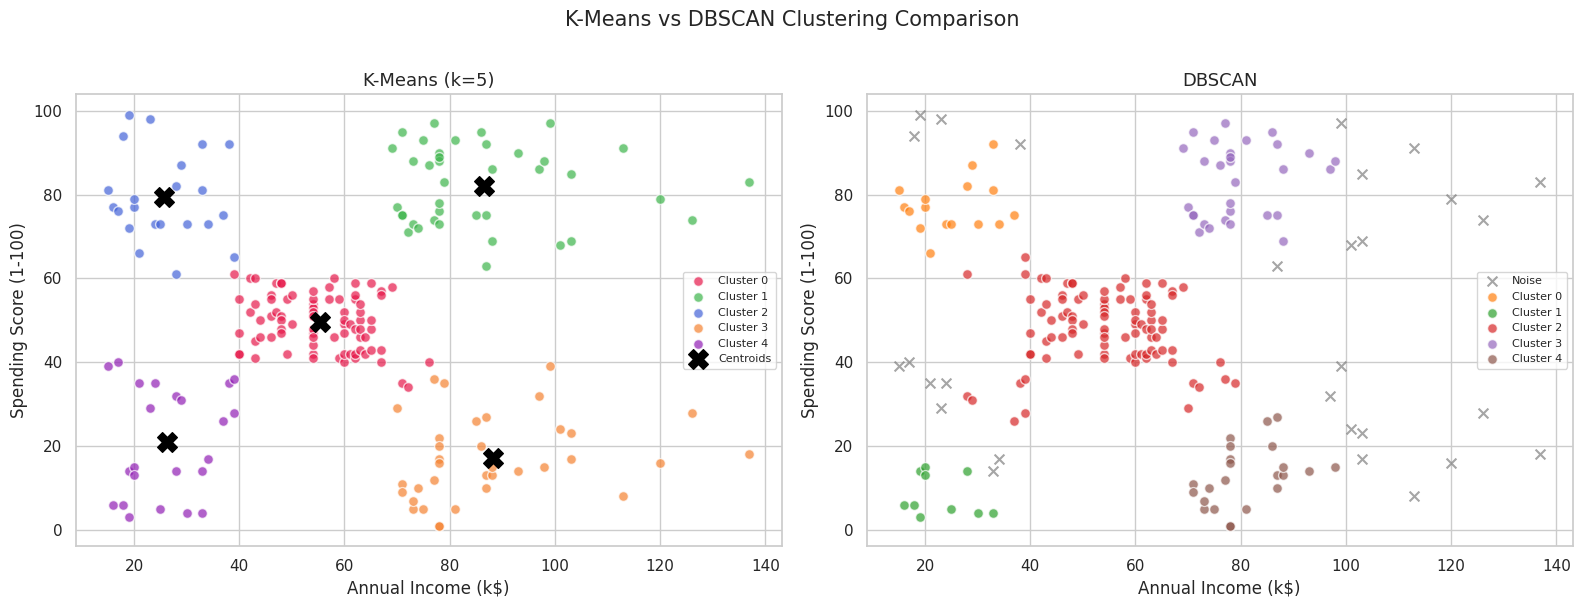

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for i in range(optimal_k):
    mask = data['KMeans_Cluster'] == i
    axes[0].scatter(
        data.loc[mask, 'Annual Income (k$)'],
        data.loc[mask, 'Spending Score (1-100)'],
        color=colors[i], label=f'Cluster {i}', s=50, alpha=0.7, edgecolors='white'
    )
axes[0].scatter(centers_original[:, 0], centers_original[:, 1],
                s=200, c='black', marker='X', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k={optimal_k})', fontsize=13)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(fontsize=8)

# DBSCAN
for idx, label in enumerate(unique_labels):
    mask = data['DBSCAN_Cluster'] == label
    cluster_name = 'Noise' if label == -1 else f'Cluster {label}'
    color = 'gray' if label == -1 else palette[idx]
    marker = 'x' if label == -1 else 'o'
    axes[1].scatter(
        data.loc[mask, 'Annual Income (k$)'],
        data.loc[mask, 'Spending Score (1-100)'],
        c=[color], label=cluster_name, s=50, alpha=0.7,
        marker=marker, edgecolors='white' if label != -1 else 'none'
    )
axes[1].set_title('DBSCAN', fontsize=13)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(fontsize=8)

plt.suptitle('K-Means vs DBSCAN Clustering Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

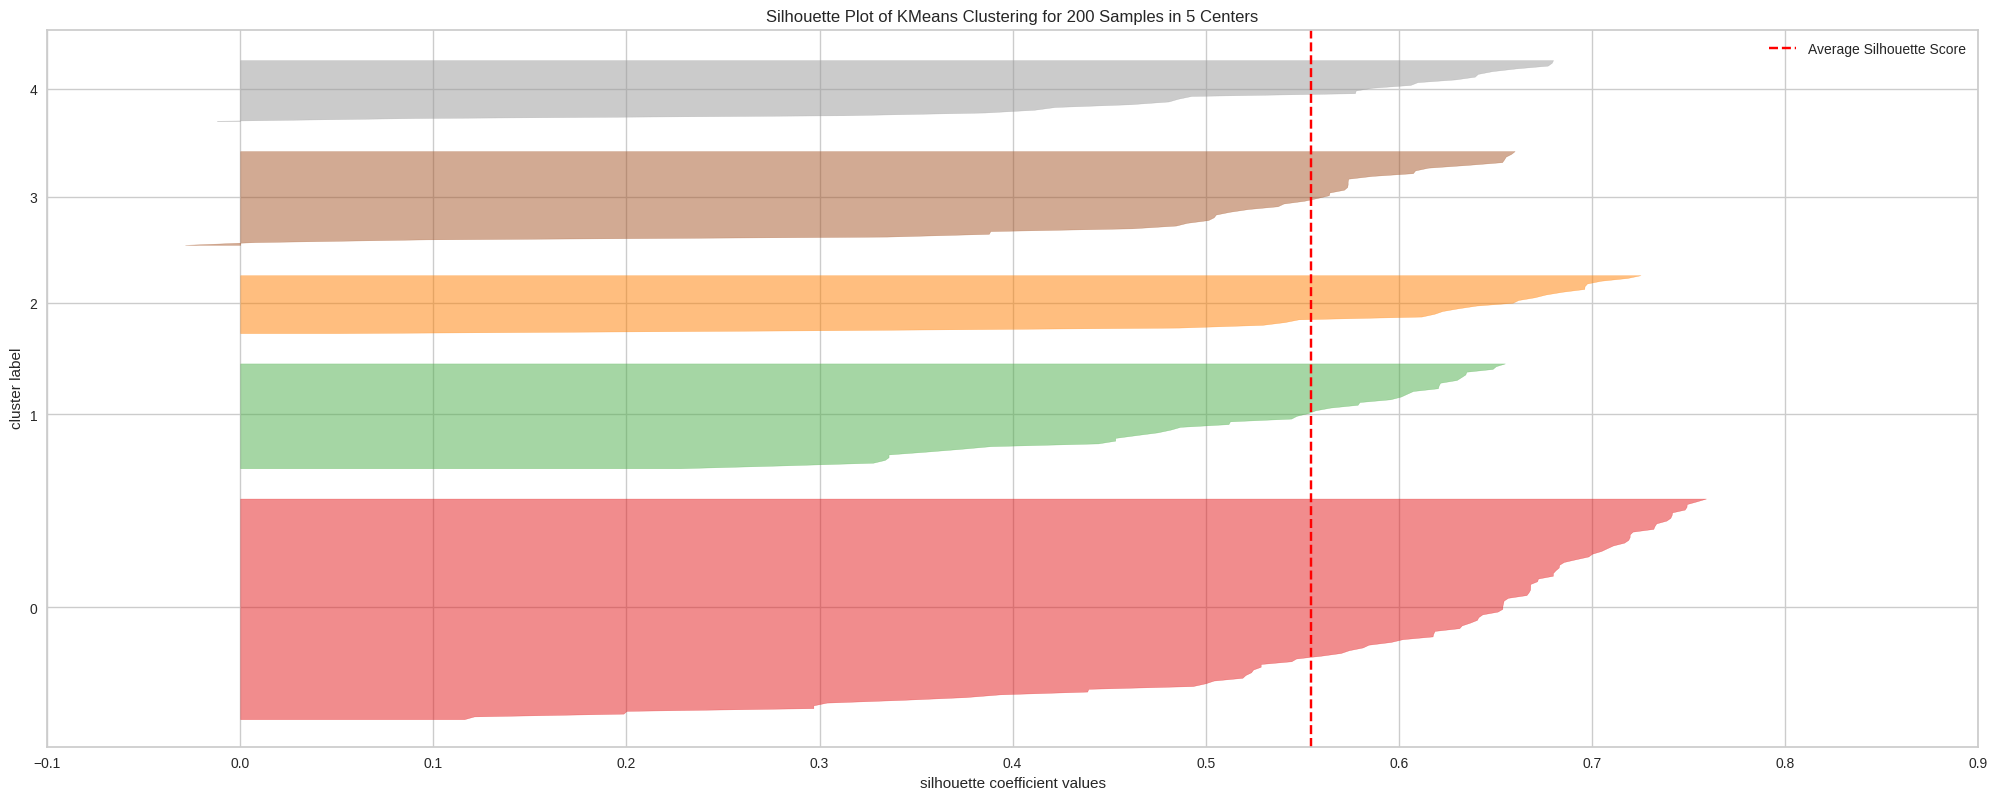

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [21]:
from yellowbrick.cluster import SilhouetteVisualizer

fig = plt.figure(figsize=(20, 8))

# Silhouette Plot for K=5
model_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
visualizer5 = SilhouetteVisualizer(model_5)
visualizer5.fit(X_scaled)
plt.title("Silhouette Plot (K=5)", fontsize=15)
plt.tight_layout()
visualizer5.show()

### Comparison K-Means with DBSCAN

- **K-Means vs. DBSCAN**: While K-Means produced 5 well-separated, spherical-like clusters, DBSCAN (with optimized `eps=0.45`, `min_samples=10`) also found 5 clusters and identified 29 noise points. The Silhouette Score for K-Means (0.5547) was slightly lower than for DBSCAN (0.5736 excluding noise), suggesting marginally better intra-cluster cohesion for DBSCAN's assigned points.

#### Strengths & Weaknesses

| | K-Means | DBSCAN |
|---|---|---|
| **Strengths** | Fast, scalable, clean equal-weight segments | Finds arbitrary shapes, auto-detects outliers, no need to pre-specify k |
| **Weaknesses** | Assumes spherical clusters; forces every point into a cluster; sensitive to outliers | Sensitive to `eps`/`min_samples`; struggles with clusters of varying density |

#### Suitability for This Dataset

For the Mall Customer dataset, **K-Means is the more suitable choice**. The 2D scatter plot shows relatively compact, roughly spherical groupings — precisely the geometry K-Means handles best. All 200 customers are assigned to a meaningful segment, which is ideal for targeted marketing campaigns.

DBSCAN's strength here is its ability to flag the **29 anomalous customers** that don't fit any dense region. However, its slight difficulty with this dataset stems from the clusters having *similar density* — the boundary between 'cluster edge' and 'noise' is not dramatic, which leads to a relatively high noise rate (14.5%) and some instability in cluster boundaries. DBSCAN would outperform K-Means if the clusters had irregular or non-convex shapes, or if outlier detection were the primary goal.

# 8. Hierarchical Clustering (Dendrogram)

As discussed in **Lecture 5**, we implement Hierarchical Clustering to visualize the "Taxonomy" of our customers.

**Ward Linkage Selection:** We chose **Ward's method** as our linkage criterion. Unlike *Single Linkage* (which is sensitive to noise) or *Complete Linkage* (which can create compact but distant clusters), Ward's method minimizes the **total within-cluster variance**. This results in spherical, evenly sized clusters that better reflect our K-Means results.

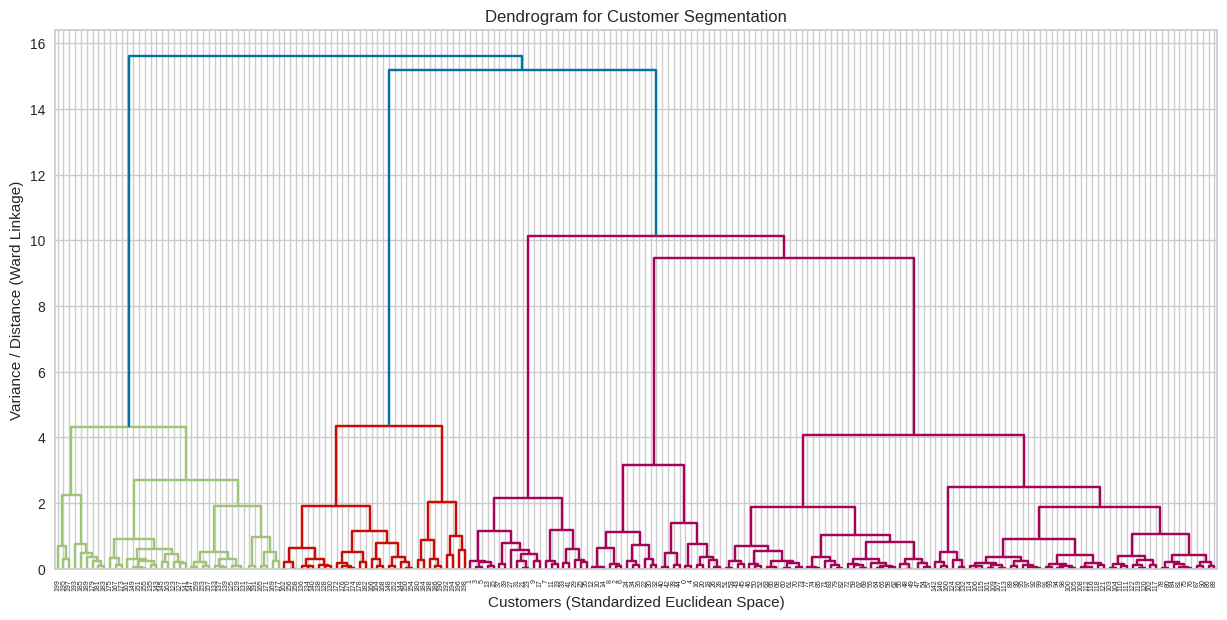

In [22]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 7))
# As discussed in Lecture 5, we use 'Ward' linkage to minimize the variance within clusters.
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Customer Segmentation')
plt.xlabel('Customers (Standardized Euclidean Space)')
plt.ylabel('Variance / Distance (Ward Linkage)')
plt.show()

## 9. Evaluation Metrics

In [23]:
# Silhouette Score for K-Means
km_sil = silhouette_score(X_scaled, data['KMeans_Cluster'])
print(f'K-Means Silhouette Score:  {km_sil:.4f}')

# Silhouette Score for DBSCAN (exclude noise points)
dbscan_mask = data['DBSCAN_Cluster'] != -1
if dbscan_mask.sum() > 1 and len(data.loc[dbscan_mask, 'DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[dbscan_mask], data.loc[dbscan_mask, 'DBSCAN_Cluster'])
    print(f'DBSCAN Silhouette Score:   {db_sil:.4f}')
else:
    print('DBSCAN: Not enough clusters for silhouette score.')

print(f'\nDBSCAN Noise Points:       {n_noise} ({n_noise/len(data)*100:.1f}%)')

print('\n--- Notes ---')
print('Silhouette Score ranges from -1 to 1.')
print('Higher values indicate better-defined clusters.')
print('DBSCAN automatically detects noise points (label = -1).')

K-Means Silhouette Score:  0.5547
DBSCAN Silhouette Score:   0.5736

DBSCAN Noise Points:       29 (14.5%)

--- Notes ---
Silhouette Score ranges from -1 to 1.
Higher values indicate better-defined clusters.
DBSCAN automatically detects noise points (label = -1).


In [24]:
from sklearn.metrics import davies_bouldin_score

# Davies-Bouldin Score for K-Means
km_dbi = davies_bouldin_score(X_scaled, data['KMeans_Cluster'])
print(f'\nK-Means Davies-Bouldin Index: {km_dbi:.4f}')

# Davies-Bouldin Score for DBSCAN (excluding noise points)
if dbscan_mask.sum() > 1 and len(data.loc[dbscan_mask, 'DBSCAN_Cluster'].unique()) > 1:
    db_dbi = davies_bouldin_score(X_scaled[dbscan_mask], data.loc[dbscan_mask, 'DBSCAN_Cluster'])
    print(f'DBSCAN Davies-Bouldin Index: {db_dbi:.4f}')
else:
    print('DBSCAN: Not enough clusters for Davies-Bouldin Index.')

print('\n--- Davies-Bouldin Notes ---')
print('The Davies-Bouldin Index measures the average similarity between clusters.')
print('A LOWER score indicates better clustering (clusters are farther apart and less dispersed).')
print('The minimum possible score is 0.0.')


K-Means Davies-Bouldin Index: 0.5722
DBSCAN Davies-Bouldin Index: 0.4830

--- Davies-Bouldin Notes ---
The Davies-Bouldin Index measures the average similarity between clusters.
A LOWER score indicates better clustering (clusters are farther apart and less dispersed).
The minimum possible score is 0.0.


## 10. Summary & Insights

After clustering the Mall Customer data using Annual Income and Spending Score, the following segments were identified (matching the K-Means cluster profiles from Section 5.4):

| Cluster | Income | Spending | Customer Type |
|---------|--------|----------|---------------|
| 0 | Mid | Mid | Average/Target customers |
| 1 | High | High | Premium/loyal customers |
| 2 | Low | High | Impulsive/targetable shoppers |
| 3 | High | Low | Conservative/savers |
| 4 | Low | Low | Budget shoppers |

**K-Means** produces clean, well-defined clusters and is ideal when the number of groups is known. It assumes roughly spherical cluster shapes and can be sensitive to outliers, as every point is forced into a cluster regardless of how well it fits.

**DBSCAN** identifies clusters of arbitrary shape and automatically flags outliers as noise — useful for detecting unusual customer behavior. Its main limitation is sensitivity to the choice of `eps` and `min_samples`, and it can struggle when clusters have very different densities.

**When to use each**: Use K-Means when you have a good estimate of the number of segments and want clean, balanced groups for targeted marketing. Use DBSCAN when you want to discover natural density-based groupings and identify anomalous customers without assuming a fixed number of clusters.